   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.9 MB/s eta 0:00:00


AD_Status,Treatment,Training,Memory
1,1,12,10
1,1,15,12
1,1,13,13
1,1,12,10
1,1,14,13
1,2,15,13
1,2,17,13
1,2,16,14
1,2,17,15
1,2,14,11


AD_Status,Treatment,mean,std,min,max
1,1,13.200,1.304,12,15
1,2,15.800,1.304,14,17
1,3,15.200,1.924,13,18
1,4,13.600,1.140,12,15
2,1,15.400,1.817,13,17
2,2,15.800,1.789,14,18
2,3,15.200,1.924,13,18
2,4,13.600,1.140,12,15


AD_Status,Treatment,mean,std,min,max
1,1,11.600,1.517,10,13
1,2,13.200,1.483,11,15
1,3,12.400,2.074,10,15
1,4,11.200,1.304,10,13
2,1,8.600,0.894,8,10
2,2,7.600,1.949,5,10
2,3,8.200,0.837,7,9
2,4,6.600,2.074,4,9


index,sum_sq,df,F,PR(>F)
C(AD_Status),3.025,1,1.216,0.278
C(Treatment),28.275,3,3.789,0.020
C(AD_Status):C(Treatment),9.075,3,1.216,0.320
Residual,79.600,32,nan,nan


...

Variable,Levene Statistic,p-value
Training,0.435,0.873
Memory,0.827,0.572



TRAINING EFFECT SIZE


Source,SS,DF,MS,F,p_unc,np2
AD_Status,3.025,1,3.025,1.216,0.278356,0.037
Treatment,28.275,3,9.425,3.789,0.019678,0.262
AD_Status * Treatment,9.075,3,3.025,1.216,0.319771,0.102
Residual,79.600,32,2.487,nan,nan,nan



MEMORY EFFECT SIZE


Source,SS,DF,MS,F,p_unc,np2
AD_Status,189.225,1,189.225,75.313,0.000000,0.702
Treatment,14.475,3,4.825,1.920,0.146118,0.153
AD_Status * Treatment,8.675,3,2.892,1.151,0.343626,0.097
Residual,80.400,32,2.512,nan,nan,nan


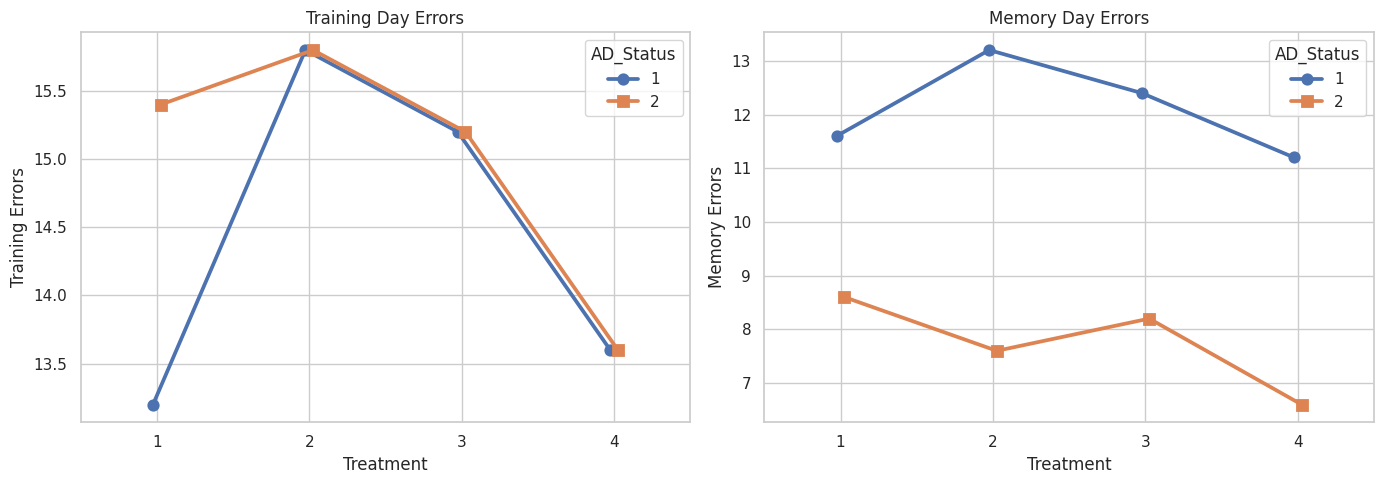


TRAINING DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on training day errors.

MEMORY DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on memory day errors.

ASSUMPTION CHECKING

Shapiro-Wilk tests were conducted to assess normality
while Levene’s tests were used to examine homogeneity
of variances.



In [1]:
# DATA DESCRIPTION

# Install required package
!pip install pingouin --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro, levene
from IPython.display import display, HTML

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

import pingouin as pg

pd.options.display.float_format = '{:.3f}'.format
sns.set(style="whitegrid")

def print_header(title):
    display(HTML(
        f"""
        <h2 style='color:#2c3e50;
        border-bottom:2px solid #2c3e50;
        padding-bottom:5px;'>
        {title}
        </h2>
        """
    ))

data = {
    "AD_Status": [
        1,1,1,1,1,
        1,1,1,1,1,
        1,1,1,1,1,
        1,1,1,1,1,

        2,2,2,2,2,
        2,2,2,2,2,
        2,2,2,2,2,
        2,2,2,2,2
    ],

    "Treatment": [
        1,1,1,1,1,
        2,2,2,2,2,
        3,3,3,3,3,
        4,4,4,4,4,

        1,1,1,1,1,
        2,2,2,2,2,
        3,3,3,3,3,
        4,4,4,4,4
    ],

    "Training": [
        12,15,13,12,14,
        15,17,16,17,14,
        13,14,18,15,16,
        14,13,12,14,15,

        17,16,17,14,13,
        14,18,16,17,14,
        13,14,18,15,16,
        14,13,12,14,15
    ],

    "Memory": [
        10,12,13,10,13,
        13,13,14,15,11,
        12,11,15,10,14,
        12,11,10,13,10,

        9,8,10,8,8,
        7,10,5,9,7,
        8,7,9,8,9,
        7,9,5,8,4
    ]
}

df = pd.DataFrame(data)

# =========================================================
# DISPLAY DATASET
# =========================================================

print_header("Alzheimer's Mice Dataset")

display(
    df.style.hide(axis="index")
)

# =========================================================
# CONVERT VARIABLES TO CATEGORICAL
# =========================================================

df["AD_Status"] = df["AD_Status"].astype("category")
df["Treatment"] = df["Treatment"].astype("category")

# =========================================================
# DESCRIPTIVE STATISTICS
# =========================================================

print_header("Descriptive Statistics for Training")

training_desc = (
    df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )["Training"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

display(
    training_desc.style
    .hide(axis="index")
    .format({
        "mean": "{:.3f}",
        "std": "{:.3f}"
    })
)

print_header("Descriptive Statistics for Memory")

memory_desc = (
    df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )["Memory"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

display(
    memory_desc.style
    .hide(axis="index")
    .format({
        "mean": "{:.3f}",
        "std": "{:.3f}"
    })
)

# =========================================================
# TWO-WAY ANOVA : TRAINING
# =========================================================

print_header("Two-Way ANOVA for Training")

model_training = ols(
    'Training ~ C(AD_Status) * C(Treatment)',
    data=df
).fit()

anova_training = anova_lm(
    model_training,
    typ=2
).reset_index()

display(
    anova_training.style
    .hide(axis="index")
    .format({
        "sum_sq": "{:.3f}",
        "df": "{:.0f}",
        "F": "{:.3f}",
        "PR(>F)": "{:.3f}"
    })
)

# =========================================================
# TWO-WAY ANOVA : MEMORY
# =========================================================

print_header("Two-Way ANOVA for Memory")

model_memory = ols(
    'Memory ~ C(AD_Status) * C(Treatment)',
    data=df
).fit()

anova_memory = anova_lm(
    model_memory,
    typ=2
).reset_index()

display(
    anova_memory.style
    .hide(axis="index")
    .format({
        "sum_sq": "{:.3f}",
        "df": "{:.0f}",
        "F": "{:.3f}",
        "PR(>F)": "{:.3f}"
    })
)

# =========================================================
# ASSUMPTION CHECKING
# =========================================================

print_header("Assumption Checking")

# =========================================================
# SHAPIRO-WILK TEST
# =========================================================

print_header("Shapiro-Wilk Test for Normality")

training_residuals = model_training.resid
memory_residuals = model_memory.resid

shapiro_training = shapiro(training_residuals)
shapiro_memory = shapiro(memory_residuals)

normality_df = pd.DataFrame({
    "Variable": ["Training", "Memory"],
    "W Statistic": [
        shapiro_training.statistic,
        shapiro_memory.statistic
    ],
    "p-value": [
        shapiro_training.pvalue,
        shapiro_memory.pvalue
    ]
})

display(
    normality_df.style
    .hide(axis="index")
    .format({
        "W Statistic": "{:.3f}",
        "p-value": "{:.3f}"
    })
)

# =========================================================
# LEVENE TEST
# =========================================================

print_header("Levene Test for Homogeneity")

groups_training = [
    group["Training"].values
    for _, group in df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )
]

groups_memory = [
    group["Memory"].values
    for _, group in df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )
]

levene_training = levene(*groups_training)
levene_memory = levene(*groups_memory)

levene_df = pd.DataFrame({
    "Variable": ["Training", "Memory"],
    "Levene Statistic": [
        levene_training.statistic,
        levene_memory.statistic
    ],
    "p-value": [
        levene_training.pvalue,
        levene_memory.pvalue
    ]
})

display(
    levene_df.style
    .hide(axis="index")
    .format({
        "Levene Statistic": "{:.3f}",
        "p-value": "{:.3f}"
    })
)

# =========================================================
# EFFECT SIZE
# =========================================================

print_header("Effect Size (Partial Eta Squared)")

anova_pg_training = pg.anova(
    dv="Training",
    between=["AD_Status", "Treatment"],
    data=df,
    detailed=True
)

anova_pg_memory = pg.anova(
    dv="Memory",
    between=["AD_Status", "Treatment"],
    data=df,
    detailed=True
)

print("\nTRAINING EFFECT SIZE")

display(
    anova_pg_training.style
    .hide(axis="index")
    .format({
        "SS": "{:.3f}",
        "DF": "{:.0f}",
        "MS": "{:.3f}",
        "F": "{:.3f}",
        "p-unc": "{:.3f}",
        "np2": "{:.3f}"
    })
)

print("\nMEMORY EFFECT SIZE")

display(
    anova_pg_memory.style
    .hide(axis="index")
    .format({
        "SS": "{:.3f}",
        "DF": "{:.0f}",
        "MS": "{:.3f}",
        "F": "{:.3f}",
        "p-unc": "{:.3f}",
        "np2": "{:.3f}"
    })
)

# =========================================================
# VISUALIZATIONS
# =========================================================

print_header("Interaction Plots")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# TRAINING PLOT
# ---------------------------------------------------------

sns.pointplot(
    data=df,
    x="Treatment",
    y="Training",
    hue="AD_Status",
    dodge=True,
    markers=["o", "s"],
    capsize=.1,
    errorbar=None,
    ax=axes[0]
)

axes[0].set_title("Training Day Errors")
axes[0].set_xlabel("Treatment")
axes[0].set_ylabel("Training Errors")
axes[0].grid(True)

# ---------------------------------------------------------
# MEMORY PLOT
# ---------------------------------------------------------

sns.pointplot(
    data=df,
    x="Treatment",
    y="Memory",
    hue="AD_Status",
    dodge=True,
    markers=["o", "s"],
    capsize=.1,
    errorbar=None,
    ax=axes[1]
)

axes[1].set_title("Memory Day Errors")
axes[1].set_xlabel("Treatment")
axes[1].set_ylabel("Memory Errors")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# =========================================================
# APA STYLE INTERPRETATION
# =========================================================

print_header("APA Style Interpretation")

print("""
TRAINING DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on training day errors.

MEMORY DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on memory day errors.

ASSUMPTION CHECKING

Shapiro-Wilk tests were conducted to assess normality
while Levene’s tests were used to examine homogeneity
of variances.
""")